Parsing log file: ../../../experiments_intersec/exp_diabetes.log
Successfully parsed 7 models
Successfully parsed 4 intersections (2-way/3-way).

FAIRNESS ANALYSIS SUMMARY

Most Unfair Attribute: age (avg score: 1.224)
Most Fair Attribute: gender (avg score: 0.180)

Models Analyzed: 7
Attributes Evaluated: 3

Average Raw Fairness Score by Attribute:
  age                 : 1.224
  race                : 0.339
  gender              : 0.180



Generating fairness score plot...
Figures saved as: fig_fairness.pdf and fig_fairness.png
Generating sample distribution plot...
Figures saved as: fig_fairness.pdf and fig_fairness.png
Generating sample distribution plot...
Sample distribution saved as: fig_samples.pdf and fig_samples.png
Generating intersection ranking plot...
Sample distribution saved as: fig_samples.pdf and fig_samples.png
Generating intersection ranking plot...
Intersection ranking saved as: fig_intersections.pdf and fig_intersections.png

Visualization complete!
Files generated

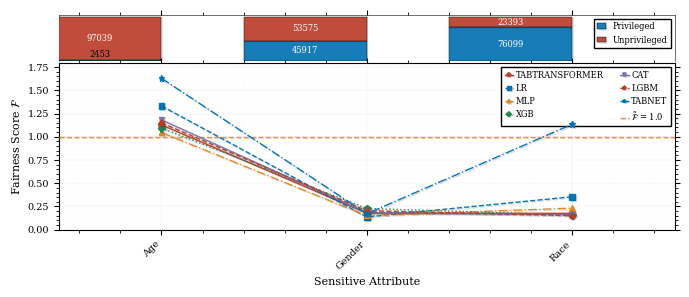

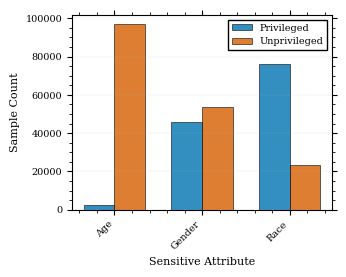

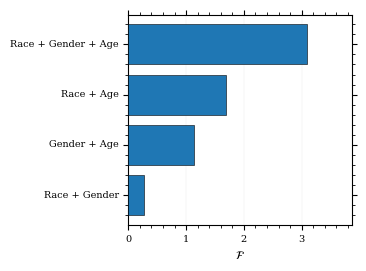

In [2]:
import re
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from pathlib import Path


def parse_experiment_log(log_file_path):
    """
    Parse the experiment log file and extract fairness metrics for each model.
    
    Args:
        log_file_path: Path to the .log file
        
    Returns:
        dict: Dictionary with model names as keys and list of attribute data as values
        list: List of intersection dicts (if found) with 'attribute' and 'raw_fairness'
    """
    with open(log_file_path, 'r') as f:
        content = f.read()
    
    # Find all model sections (from tabtransformer to tabnet)
    model_pattern = r"Model '(\w+)':\s*\+[-+]+\+.*?\+[-+]+\+(.*?)\+[-+]+\+"
    models_data = {}
    
    for match in re.finditer(model_pattern, content, re.DOTALL):
        model_name = match.group(1)
        table_content = match.group(2)
        
        # Stop if we've reached the combinations analysis
        if 'Running 2-way and 3-way' in content[:match.start()]:
            break
        
        # Parse table rows
        attributes = []
        row_pattern = r'\|\s*([^\|]+?)\s*\|\s*([\d.]+)\s*\|\s*([\d.]+)\s*\|\s*([\d.]+)\s*\|\s*(\d+)\s*\|\s*(\d+)\s*\|'
        
        for row_match in re.finditer(row_pattern, table_content):
            attribute = row_match.group(1).strip()
            # Skip header row
            if attribute.lower() in ['attribute', '']:
                continue
                
            attributes.append({
                'attribute': attribute,
                'raw_fairness': float(row_match.group(2)),
                'normalized_fairness': float(row_match.group(3)),
                'balanced_accuracy': float(row_match.group(4)),
                'privileged_n': int(row_match.group(5)),
                'unprivileged_n': int(row_match.group(6))
            })
        
        if attributes:
            models_data[model_name] = attributes

       # --- Attempt to parse intersection (2-way and 3-way) analysis if present ---
    intersections = []
    idx = content.find('Running 2-way and 3-way')
    if idx != -1:
        rest = content[idx:]
        # assume combination tables have the same columns as single-attribute tables:
        # | combination | raw | normalized | balanced_acc | priv_n | unpriv_n |
        row_pattern_comb = (
            r'\|\s*([^\|]+?)\s*\|'      # combination name
            r'\s*([\d.]+)\s*\|'         # raw fairness
            r'\s*([\d.]+)\s*\|'         # normalized fairness
            r'\s*([\d.]+)\s*\|'         # balanced accuracy
            r'\s*(\d+)\s*\|'            # privileged_n
            r'\s*(\d+)\s*\|'            # unprivileged_n
        )

        for row_match in re.finditer(row_pattern_comb, rest):
            attribute = row_match.group(1).strip()
            # skip header or irrelevant lines
            if attribute.lower() in ['attribute', 'combination', '']:
                continue

            raw = float(row_match.group(2))
            norm = float(row_match.group(3))
            bal = float(row_match.group(4))
            priv_n = int(row_match.group(5))
            unpriv_n = int(row_match.group(6))

            intersections.append({
                'attribute': attribute,
                'raw_fairness': raw,
                'normalized_fairness': norm,
                'balanced_accuracy': bal,
                'privileged_n': priv_n,
                'unprivileged_n': unpriv_n,
            })
    
    return models_data, intersections

def clean_intersection_label(attr, known_attributes):
    """
    Produce a clean and consistent intersection label:
    - Tries to segment combined tokens like "age_ever_married" into known attributes
      using a DP segmentation on the underscore-removed string.
    - Falls back to splitting by separators (&, +, ,) or underscores when segmentation fails.
    - Maps keys back to pretty names via known_attributes (keys are normalized: lower + underscores).
    - Joins components with ' + '.
    """
    # Normalize input
    s_norm = attr.strip().lower().replace(" ", "_")

    # Prepare known keys: map normalized-without-underscores -> original normalized key
    # e.g. 'ever_married' -> 'evermarried' -> map 'evermarried' -> 'ever_married'
    key_no_map = {}
    for k in known_attributes.keys():
        kn = k.strip().lower().replace(" ", "_")
        k_no = kn.replace("_", "")
        key_no_map[k_no] = kn

    s_no = s_norm.replace("_", "")

    # Dynamic programming segmentation: dp[i] = list of normalized keys that compose s_no[:i]
    dp = [None] * (len(s_no) + 1)
    dp[0] = []

    # Try to segment using known keys (prefer longer matches implicitly by trying all)
    for i in range(len(s_no)):
        if dp[i] is None:
            continue
        # iterate through candidate key_nos
        for k_no, kn in key_no_map.items():
            ln = len(k_no)
            if s_no[i:i+ln] == k_no:
                if dp[i+ln] is None:
                    dp[i+ln] = dp[i] + [kn]

    if dp[len(s_no)]:
        # Successful segmentation — map to pretty names
        parts = dp[len(s_no)]
        pretty_parts = []
        for kn in parts:
            pretty = known_attributes.get(kn, kn.replace("_", " ").title())
            pretty_parts.append(pretty)
        return " + ".join(pretty_parts)

    # --- fallback: try splitting by common separators (&, +, ,) and then attempt to map each piece ---
    raw_parts = re.split(r'\s*[&,+]\s*', attr)

    cleaned_parts = []
    for p in raw_parts:
        p_norm = p.strip().lower().replace(" ", "_")
        # direct exact match
        if p_norm in known_attributes:
            cleaned_parts.append(known_attributes[p_norm])
            continue

        # try underscored segmentation: e.g., 'age_ever_married' -> try to match to known keys by underscore-splits
        unders_parts = p_norm.split("_")
        # attempt to greedily join unders_parts into known keys (try longest-first joining)
        j = 0
        matched = []
        while j < len(unders_parts):
            found = False
            # attempt to find the longest span that matches a known key
            for end in range(len(unders_parts), j, -1):
                candidate = "_".join(unders_parts[j:end])
                if candidate in known_attributes:
                    matched.append(known_attributes[candidate])
                    j = end
                    found = True
                    break
            if not found:
                # can't match any span; break to fallback
                matched = []
                break

        if matched:
            cleaned_parts.extend(matched)
            continue

        # 2. Try fuzzy / partial match against known keys
        best_match = None
        for ka in known_attributes:
            if p_norm == ka:
                best_match = ka
                break
            if p_norm in ka or ka in p_norm:
                best_match = ka
                break

        if best_match:
            cleaned_parts.append(known_attributes[best_match])
        else:
            # 3. Fallback: format raw text
            cleaned_parts.append(p.replace("_", " ").title())

    # remove duplicates while preserving order (in case segmentation created repeats)
    seen = set()
    final_parts = []
    for cp in cleaned_parts:
        if cp not in seen:
            final_parts.append(cp)
            seen.add(cp)

    return " + ".join(final_parts)

def create_sample_distribution_plot(models_data, output_file='fig_samples', single_column=True):
    """
    Create a publication-quality plot showing sample distribution imbalance.
    
    Args:
        models_data: Dictionary from parse_experiment_log
        output_file: Base filename for output (without extension)
        single_column: If True, use single-column width
    """
    # Extract all unique attributes
    all_attributes = []
    for model_attrs in models_data.values():
        for attr_data in model_attrs:
            if attr_data['attribute'] not in all_attributes:
                all_attributes.append(attr_data['attribute'])
    
    # Calculate average sample counts across models
    sample_data = {}
    for attr in all_attributes:
        privileged_counts = []
        unprivileged_counts = []
        
        for model_attrs in models_data.values():
            attr_data = next((a for a in model_attrs if a['attribute'] == attr), None)
            if attr_data:
                privileged_counts.append(attr_data['privileged_n'])
                unprivileged_counts.append(attr_data['unprivileged_n'])
        
        sample_data[attr] = {
            'privileged': np.mean(privileged_counts),
            'unprivileged': np.mean(unprivileged_counts),
            'ratio': np.mean(unprivileged_counts) / np.mean(privileged_counts)
        }
    
    # Figure setup
    if single_column:
        fig = plt.figure(figsize=(3.25, 2.5))
    else:
        fig = plt.figure(figsize=(7.0, 2.5))
    
    plt.rc('xtick', top=True)
    plt.rc('ytick', right=True)
    plt.rc('font', family='serif')
    plt.rc('text', usetex=False)
    plt.rc('xtick', labelsize=7)
    plt.rc('ytick', labelsize=7)
    plt.rc('axes', labelsize=8)
    plt.rc('legend', fontsize=7, handlelength=2.0)
    
    gs = plt.GridSpec(1, 1)
    ax = plt.subplot(gs[0, 0])
    ax.minorticks_on()
    
    # Prepare data
    x_pos = np.arange(len(all_attributes))
    width = 0.35
    
    privileged = [sample_data[attr]['privileged'] for attr in all_attributes]
    unprivileged = [sample_data[attr]['unprivileged'] for attr in all_attributes]
    
    # Create grouped bar chart
    bars1 = ax.bar(x_pos - width/2, privileged, width, 
                   label='Privileged', color='#0173B2', alpha=0.8, 
                   edgecolor='black', linewidth=0.5)
    bars2 = ax.bar(x_pos + width/2, unprivileged, width,
                   label='Unprivileged', color='#D55E00', alpha=0.8,
                   edgecolor='black', linewidth=0.5)
    
    # Configure axes
    ax.set_xlabel(r'Sensitive Attribute')
    ax.set_ylabel(r'Sample Count')
    ax.set_xticks(x_pos)
    
    formatted_labels = [attr.replace('_', ' ').title() for attr in all_attributes]
    ax.set_xticklabels(formatted_labels, rotation=45, ha='right')
    
    # Grid
    ax.grid(True, which='major', axis='y', linestyle='-', 
            linewidth=0.3, alpha=0.3, zorder=0)
    
    # Legend
    ax.legend(loc='upper right', frameon=True, fancybox=False, 
             edgecolor='black', framealpha=1.0)
    
    # Adjust layout
    if single_column:
        axleft = 0.16
        axbottom = 0.18
        axright = 0.96
        axtop = 0.96
    else:
        axleft = 0.10
        axbottom = 0.16
        axright = 0.98
        axtop = 0.96
    
    fig.subplots_adjust(left=axleft, bottom=axbottom, right=axright, top=axtop)
    
    # Save
    plt.savefig(f'{output_file}.pdf', dpi=300, bbox_inches='tight')
    plt.savefig(f'{output_file}.png', dpi=300, bbox_inches='tight')
    
    print(f"Sample distribution saved as: {output_file}.pdf and {output_file}.png")
    
    return fig, ax

import textwrap

def create_intersection_ranking_plot(intersections, models_data,
                                     output_file='fig_intersections',
                                     single_column=True, top_k=None,
                                     wrap_width=100,
                                     outside_fontfamily='serif',
                                     inside_fontfamily='serif'):
    """
    Create a small ranking plot (same size as sample distribution) for intersections (2-way & 3-way).

    intersections: list of dicts with keys:
        'attribute', 'raw_fairness', optionally 'normalized_fairness',
        and ideally 'privileged_n', 'unprivileged_n'
    models_data: dictionary (used to build canonical single-attribute pretty names)
    top_k: if provided, plot only top_k intersections (by raw_fairness)
    wrap_width: approximate max characters per wrapped line for labels
    outside_fontfamily / inside_fontfamily:
        font families used for ratio labels outside and inside bars.
    """
    if not intersections:
        print("No intersection (2-way/3-way) data found — skipping intersection ranking plot.")
        return None, None

    # Sort by raw fairness (descending for ranking)
    intersections_sorted = sorted(intersections, key=lambda x: x['raw_fairness'], reverse=True)
    if top_k:
        intersections_sorted = intersections_sorted[:top_k]

    # Build known attribute dictionary from single attributes (canonical pretty names)
    known_attributes = {}
    for model_attrs in models_data.values():
        for a in model_attrs:
            key = a['attribute'].strip().lower().replace(" ", "_")
            pretty = a['attribute'].replace("_", " ").title()
            known_attributes[key] = pretty

    # Convert intersection labels using clean_intersection_label()
    raw_pretty_labels = []
    values = []
    for it in intersections_sorted:
        pretty_label = clean_intersection_label(it['attribute'], known_attributes)
        raw_pretty_labels.append(pretty_label)
        values.append(it['raw_fairness'])

    # Wrap labels nicely while preserving " + " separators:
    wrapped_labels = []
    max_line_chars = 0
    for lbl in raw_pretty_labels:
        comps = [c.strip() for c in lbl.split(' + ')]
        joined = " + ".join(comps)
        lines = textwrap.wrap(joined, width=wrap_width,
                              break_long_words=False, break_on_hyphens=False)
        # If textwrap produced more than 3 lines, fall back to component-per-line
        if len(lines) > 3:
            lines = []
            for i, c in enumerate(comps):
                if i == 0:
                    lines.append(c)
                else:
                    lines.append("+ " + c)
        stacked = "\n".join(lines)
        wrapped_labels.append(stacked)
        for L in lines:
            max_line_chars = max(max_line_chars, len(L))

    # Decide fontsize for ytick labels based on number of labels
    n_labels = len(wrapped_labels)
    if n_labels > 20:
        y_fontsize = 5.0
    elif n_labels > 12:
        y_fontsize = 6.0
    elif n_labels > 8:
        y_fontsize = 6.5
    else:
        y_fontsize = 7.0

    # Determine left margin dynamically from max_line_chars
    extra = min(0.45, 0.008 * max_line_chars)
    base_left = 0.12 if single_column else 0.10
    axleft = base_left + extra

    # Figure setup - same size as sample distribution plot
    if single_column:
        fig = plt.figure(figsize=(3.25, 2.5))
    else:
        fig = plt.figure(figsize=(7.0, 2.5))

    plt.rc('xtick', top=True)
    plt.rc('ytick', right=True)
    plt.rc('font', family='serif')
    plt.rc('text', usetex=False)
    plt.rc('xtick', labelsize=7)
    plt.rc('ytick', labelsize=7)
    plt.rc('axes', labelsize=8)
    plt.rc('legend', fontsize=7, handlelength=2.0)

    gs = plt.GridSpec(1, 1)
    ax = plt.subplot(gs[0, 0])
    ax.minorticks_on()

    # Horizontal bar chart for ranking
    y_pos = np.arange(len(wrapped_labels))
    bars = ax.barh(y_pos, values, align='center',
                   edgecolor='black', linewidth=0.4, zorder=5)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(wrapped_labels, va='center', fontsize=y_fontsize)
    ax.invert_yaxis()  # highest at top

    # X label uses \mathcal{F} for raw fairness
    ax.set_xlabel(r'$\mathcal{F}$')

    # small x limit padding, leaving extra room on the right for ratio text
    xmin = 0
    raw_max = max(values) if values else 1.0
    xmax = raw_max * 1.25  # extra room for text annotations
    ax.set_xlim(xmin, xmax)

    # Grid (vertical grid lines)
    ax.grid(True, which='major', axis='x', linestyle='-',
            linewidth=0.3, alpha=0.3, zorder=0)

    # --- Helper to place ratio either outside or inside the bar ---
    def annotate_ratio_on_bar(ax, bar, ratio_text, xmax,
                              outside_fontfamily='serif',
                              inside_fontfamily='serif',
                              fontsize=6):
        """
        Place ratio text for a bar (kept as helper but not used).
        """
        bar_width = bar.get_width()
        y_center = bar.get_y() + bar.get_height() / 2.0

        total_range = xmax - xmin
        margin = 0.04 * total_range
        space_right = xmax - bar_width

        if space_right >= margin * 1.5:
            outside_x = bar_width + margin
            ax.text(outside_x, y_center,
                    ratio_text,
                    ha='left', va='center',
                    fontsize=fontsize,
                    color='black',
                    fontfamily=outside_fontfamily)
        else:
            inside_x = bar_width - margin * 0.4
            inside_x = max(inside_x, xmin + 0.02 * total_range)
            ax.text(inside_x, y_center,
                    ratio_text,
                    ha='right', va='center',
                    fontsize=fontsize,
                    color='white',
                    fontfamily=inside_fontfamily)

    # --- Annotate U/P ratio for each intersection ---
    # Removed U/P ratio annotations from intersection plot as requested.

    # Adjust subplot margins to accommodate multi-line labels
    axbottom = 0.12 if single_column else 0.16
    axright = 0.96 if single_column else 0.98
    axtop = 0.96

    fig.subplots_adjust(left=axleft, bottom=axbottom, right=axright, top=axtop)

    # Save
    plt.savefig(f'{output_file}.pdf', dpi=300, bbox_inches='tight')
    plt.savefig(f'{output_file}.png', dpi=300, bbox_inches='tight')

    print(f"Intersection ranking saved as: {output_file}.pdf and {output_file}.png")
    return fig, ax

def create_fairness_plot(models_data, output_file='fig_fairness', single_column=True):
    """
    Create a publication-quality matplotlib visualization of fairness scores,
    using NEJM color scheme (ggsci pal_nejm-inspired) and subtle shadows for depth.
    Also includes the small stacked-bar top strip (sample distribution) with numeric
    annotations for privileged/unprivileged counts.
    """
    import matplotlib.patheffects as pe
    import math

    # NEJM palette (ggsci-inspired)
    nejm_palette = ['#bc3c29', '#0072b5', '#e18727', '#20854e', '#7876b1']

    # Extract all unique attributes (in order they appear)
    all_attributes = []
    for model_attrs in models_data.values():
        for attr_data in model_attrs:
            if attr_data['attribute'] not in all_attributes:
                all_attributes.append(attr_data['attribute'])

    # Prepare model names (for lines)
    model_names = list(models_data.keys())

    # Generate color mapping for models by cycling the NEJM palette
    colors = {}
    for i, mn in enumerate(model_names):
        colors[mn] = nejm_palette[i % len(nejm_palette)]

    # Keep line styles & markers as before (unchanged)
    line_styles = {
        'tabtransformer': '-',
        'lr': '--',
        'mlp': '-.',
        'xgb': ':',
        'cat': '-',
        'lgbm': '--',
        'tabnet': '-.'
    }
    markers = {
        'tabtransformer': 'o',
        'lr': 's',
        'mlp': '^',
        'xgb': 'D',
        'cat': 'v',
        'lgbm': 'p',
        'tabnet': '*'
    }

    # Reference ceiling
    max_raw_at_ceiling = 1

    # Figure setup
    if single_column:
        fig = plt.figure(figsize=(3.25, 2.5))
        top_strip_height = 0.45
        main_height = 1.8
    else:
        fig = plt.figure(figsize=(7.0, 2.5))
        top_strip_height = 0.5
        main_height = 1.8

    plt.rc('xtick', top=True)
    plt.rc('ytick', right=True)
    plt.rc('font', family='serif')
    plt.rc('text', usetex=False)
    plt.rc('xtick', labelsize=7)
    plt.rc('ytick', labelsize=7)
    plt.rc('axes', labelsize=8)
    plt.rc('legend', fontsize=6, handlelength=2.5)

    # GridSpec: top strip + main plot
    gs = plt.GridSpec(2, 1, height_ratios=[top_strip_height, main_height], hspace=0.02)
    ax_top = plt.subplot(gs[0, 0])
    ax = plt.subplot(gs[1, 0], sharex=ax_top)
    ax.minorticks_on()

    # --- Build average sample counts per attribute ---
    sample_data = {}
    for attr in all_attributes:
        privileged_counts = []
        unprivileged_counts = []
        for model_attrs in models_data.values():
            attr_data = next((a for a in model_attrs if a['attribute'] == attr), None)
            if attr_data:
                privileged_counts.append(attr_data['privileged_n'])
                unprivileged_counts.append(attr_data['unprivileged_n'])
        if privileged_counts:
            avg_priv = float(np.mean(privileged_counts))
            avg_unpriv = float(np.mean(unprivileged_counts))
        else:
            avg_priv = 0.0
            avg_unpriv = 0.0
        sample_data[attr] = {'privileged': avg_priv, 'unprivileged': avg_unpriv, 'total': avg_priv + avg_unpriv}

    x_positions = np.arange(len(all_attributes))
    width = 0.6

    # NEJM colors for the top strip: use two distinct but harmonious colors from the palette
    priv_color = nejm_palette[1]   # '#0072b5' (blue) - privileged
    unpriv_color = nejm_palette[0] # '#bc3c29' (reddish) - unprivileged (keeps contrast)

    privileged = [sample_data[attr]['privileged'] for attr in all_attributes]
    unprivileged = [sample_data[attr]['unprivileged'] for attr in all_attributes]

    # Top strip y-limits (compact)
    max_total = max([sample_data[attr]['total'] for attr in all_attributes]) if all_attributes else 1.0
    ax_top_ylim_max = max_total * 1.05 if max_total > 0 else 1.0
    ax_top.set_ylim(0, ax_top_ylim_max)

    # Draw stacked bars with subtle edge + slight shadow (SimplePatchShadow)
    bars_priv = ax_top.bar(x_positions - width/2, privileged, width,
                          label='Privileged', color=priv_color, alpha=0.9,
                          edgecolor='black', linewidth=0.35, zorder=3)
    bars_unpriv = ax_top.bar(x_positions - width/2, unprivileged, width, bottom=privileged,
                             label='Unprivileged', color=unpriv_color, alpha=0.9,
                             edgecolor='black', linewidth=0.35, zorder=3)

    # Add patch shadow to top bars to give subtle depth
    for patch in list(bars_priv) + list(bars_unpriv):
        patch.set_path_effects([pe.SimplePatchShadow(offset=(1.0, -1.0), alpha=0.12),
                                pe.Normal()])

    # --- Annotate numbers on the privileged / unprivileged segments ---
    # We'll place text inside the segment if it has enough height, otherwise above the segment.
    label_fontsize = 6
    # threshold in axis units (fraction of top strip y range) below which we place text above segment
    inside_threshold_frac = 0.08  # if segment height is >= 8% of strip range, write inside

    for i, (rect_priv, rect_unp) in enumerate(zip(bars_priv, bars_unpriv)):
        # Values
        val_priv = privileged[i]
        val_unp = unprivileged[i]
        total = val_priv + val_unp if (val_priv + val_unp) > 0 else 1.0

        # Coordinates and heights in data units
        priv_x = rect_priv.get_x() + rect_priv.get_width() / 2.0
        priv_h = rect_priv.get_height()
        unp_h = rect_unp.get_height()
        unp_x = rect_unp.get_x() + rect_unp.get_width() / 2.0

        # threshold in data units
        threshold = inside_threshold_frac * ax_top_ylim_max

        # privileged label
        if priv_h >= threshold:
            # place inside privileged segment (center)
            ax_top.text(priv_x, priv_h / 2.0,
                        f"{int(round(val_priv))}",
                        ha='center', va='center',
                        fontsize=label_fontsize, color='white', zorder=6)
        else:
            # place above privileged segment
            ax_top.text(priv_x, priv_h + ax_top_ylim_max * 0.015,
                        f"{int(round(val_priv))}",
                        ha='center', va='bottom',
                        fontsize=label_fontsize, color='black', zorder=6)

        # unprivileged label: need y position relative to bottom of unpriv segment
        unp_bottom = rect_unp.get_y()
        # center inside unprivileged segment if tall enough
        if unp_h >= threshold:
            ax_top.text(unp_x, unp_bottom + unp_h / 2.0,
                        f"{int(round(val_unp))}",
                        ha='center', va='center',
                        fontsize=label_fontsize, color='white', zorder=6)
        else:
            # place above the top of the stacked bar
            ax_top.text(unp_x, priv_h + unp_h + ax_top_ylim_max * 0.015,
                        f"{int(round(val_unp))}",
                        ha='center', va='bottom',
                        fontsize=label_fontsize, color='black', zorder=6)

    # Minimal formatting for top strip
    ax_top.tick_params(axis='x', which='both', bottom=False, labelbottom=False)
    ax_top.set_xticks(x_positions)
    ax_top.set_yticks([])
    ax_top.spines['bottom'].set_visible(False)
    ax_top.spines['top'].set_linewidth(0.4)
    ax_top.spines['left'].set_linewidth(0.4)
    ax_top.spines['right'].set_linewidth(0.4)
    ax_top.set_xlim(-0.5, len(all_attributes)-0.5)

    # Add a tiny legend for the strip (compact)
    ax_top.legend(['Privileged', 'Unprivileged'], loc='upper right', frameon=True,
                  fancybox=False, edgecolor='black', framealpha=1.0, fontsize=6, handlelength=1.0)

    # --- Boxplot data for main axis ---
    box_data = []
    for attr in all_attributes:
        vals = []
        for model_attrs in models_data.values():
            match = next((a for a in model_attrs if a['attribute'] == attr), None)
            if match is not None:
                vals.append(match['raw_fairness'])
        box_data.append(vals)

    nonempty_data = []
    nonempty_pos = []
    for i, vals in enumerate(box_data):
        if vals:
            nonempty_data.append(vals)
            nonempty_pos.append(x_positions[i])

    # --- Plot model lines on main axis with shadows ---
    for model_name in model_names:
        model_attrs = models_data[model_name]
        attr_to_fairness = {attr['attribute']: attr['raw_fairness'] for attr in model_attrs}
        y_values = [attr_to_fairness.get(attr, np.nan) for attr in all_attributes]

        color = colors.get(model_name, '#000000')
        linestyle = line_styles.get(model_name, '-')
        marker = markers.get(model_name, 'o')

        # Draw line with a soft shadow (SimpleLineShadow) then the actual line (Normal)
        line = ax.plot(x_positions, y_values,
                       color=color,
                       linestyle=linestyle,
                       marker=marker,
                       markersize=4,
                       linewidth=1.0,
                       label=model_name.upper(),
                       alpha=0.98,
                       zorder=10)[0]
        # Attach path effects for shadow depth
        line.set_path_effects([pe.SimpleLineShadow(offset=(0.9, -0.9), alpha=0.14), pe.Normal()])

        # Add a white halo behind markers for visibility
        ax.plot(x_positions, y_values,
                color='white',
                linestyle='',
                marker=marker,
                markersize=5.4,
                zorder=9,
                markeredgewidth=0.0,
                alpha=0.9)

    # Reference line for normalized fairness ceiling (keep as before but add subtle shadow)
    ref_line = ax.axhline(y=max_raw_at_ceiling,
               color=nejm_palette[2],  # use a NEJM color for contrast (#e18727)
               linestyle='--',
               linewidth=1.0,
               alpha=0.85,
               zorder=5,
               label=r'$\tilde\mathcal{F}$ = 1.0')
    ref_line.set_path_effects([pe.SimpleLineShadow(offset=(0.8, -0.8), alpha=0.12), pe.Normal()])

    # Axes formatting (preserve)
    ax.set_xlabel(r'Sensitive Attribute')
    ax.set_ylabel(r'Fairness Score $\mathcal{F}$')
    ax.set_xticks(x_positions)
    formatted_labels = [attr.replace('_', ' ').title() for attr in all_attributes]
    ax.set_xticklabels(formatted_labels, rotation=45, ha='right')

    # Compute y-limits for main axis using raw fairness values
    y_values_all = []
    for model_attrs in models_data.values():
        y_values_all.extend([attr['raw_fairness'] for attr in model_attrs])
    y_min = 0
    y_max = max(y_values_all) * 1.1 if y_values_all else 1.0
    ax.set_ylim(y_min, y_max)

    # Grid on main axis
    ax.grid(True, which='major', linestyle='-', linewidth=0.3, alpha=0.3, zorder=0)
    ax.grid(True, which='minor', linestyle=':', linewidth=0.2, alpha=0.2, zorder=0)

    # Legend for models (compact). Reuse the smaller legend style you had.
    if single_column:
        ax.legend(loc='upper left',
                  bbox_to_anchor=(1.02, 1.0),
                  frameon=True, fancybox=False, edgecolor='black',
                  framealpha=1.0, ncol=1,
                  fontsize=5,
                  markerscale=0.65,
                  handlelength=1.0,
                  handletextpad=0.3)
        axleft = 0.16
        axbottom = 0.12
        axright = 0.82
        axtop = 0.94
    else:
        ax.legend(loc='upper right', frameon=True, fancybox=False,
                  edgecolor='black', framealpha=1.0, ncol=2,
                  fontsize=6,
                  markerscale=0.65,
                  handlelength=1.0,
                  handletextpad=0.3)
        axleft = 0.10
        axbottom = 0.10
        axright = 0.98
        axtop = 0.96

    fig.subplots_adjust(left=axleft, bottom=axbottom, right=axright, top=axtop)

    # Save figure
    plt.savefig(f'{output_file}.pdf', dpi=300, bbox_inches='tight')
    plt.savefig(f'{output_file}.png', dpi=300, bbox_inches='tight')

    print(f"Figures saved as: {output_file}.pdf and {output_file}.png")
    return fig, ax


def print_summary_statistics(models_data):
    """Print summary statistics from the parsed data."""
    print("\n" + "="*80)
    print("FAIRNESS ANALYSIS SUMMARY")
    print("="*80)
    
    # Find most and least fair attributes overall
    attr_scores = {}
    for model_attrs in models_data.values():
        for attr_data in model_attrs:
            attr = attr_data['attribute']
            if attr not in attr_scores:
                attr_scores[attr] = []
            attr_scores[attr].append(attr_data['raw_fairness'])
    
    avg_scores = {attr: np.mean(scores) for attr, scores in attr_scores.items()}
    
    most_unfair = max(avg_scores.items(), key=lambda x: x[1])
    most_fair = min(avg_scores.items(), key=lambda x: x[1])
    
    print(f"\nMost Unfair Attribute: {most_unfair[0]} (avg score: {most_unfair[1]:.3f})")
    print(f"Most Fair Attribute: {most_fair[0]} (avg score: {most_fair[1]:.3f})")
    
    print(f"\nModels Analyzed: {len(models_data)}")
    print(f"Attributes Evaluated: {len(attr_scores)}")
    
    print("\nAverage Raw Fairness Score by Attribute:")
    for attr, score in sorted(avg_scores.items(), key=lambda x: x[1], reverse=True):
        print(f"  {attr:20s}: {score:.3f}")
    
    print("\n" + "="*80 + "\n")


def main():
    """Main function to run the fairness analysis."""
    # Configure your log file path here
    log_file = '../../../experiments_intersec/exp_diabetes.log'  # Change this to your log file path
    
    # Check if file exists
    if not Path(log_file).exists():
        print(f"Error: Log file '{log_file}' not found!")
        print("Please update the log_file variable with the correct path.")
        return
    
    print(f"Parsing log file: {log_file}")
    
    # Parse the log file (now returns models_data and intersections)
    models_data, intersections = parse_experiment_log(log_file)
    
    if not models_data:
        print("Error: No model data found in log file!")
        print("Make sure the log file contains model fairness tables.")
        return
    
    print(f"Successfully parsed {len(models_data)} models")
    if intersections:
        print(f"Successfully parsed {len(intersections)} intersections (2-way/3-way).")
    else:
        print("No intersections (2-way/3-way) detected in the log file.")
    
    # Print summary statistics
    print_summary_statistics(models_data)
    
    # Create the fairness plot
    print("\nGenerating fairness score plot...")
    create_fairness_plot(models_data, 
                        output_file='fig_fairness',
                        single_column=False)  # Change to False for double-column
    
    # Create sample distribution plot
    print("Generating sample distribution plot...")
    create_sample_distribution_plot(models_data,
                                   output_file='fig_samples',
                                   single_column=True)

    # Create intersection ranking plot (same style/size as sample distribution)
    print("Generating intersection ranking plot...")
    create_intersection_ranking_plot(intersections,
                                models_data,
                                output_file='fig_intersections',
                                single_column=True,
                                top_k=20,
                                inside_fontfamily='sans-serif')
    
    print("\nVisualization complete!")
    print("Files generated:")
    print("  - fig_fairness.pdf/.png (Raw fairness scores)")
    print("  - fig_samples.pdf/.png (Sample distribution)")
    print("  - fig_intersections.pdf/.png (Intersection ranking)")

if __name__ == '__main__':
    main()
